In [1]:
using ITensors, ITensorMPS
using ITransverse
using Plots
using ProgressMeter

In [2]:
# System Parameters

# Alcaraz's NNN Self Dual Critical model
N = 50        
lambda = 1.0    # exact critical point (self dual)
p = 0.5         # NNN term (p>0 breakes system's integrability)
dt = 0.1       
T_max = 4.0     
cutoff = 1e-10
maxdim = 200

# Physical indices
sites = siteinds("S=1/2", N)

50-element Vector{Index{Int64}}:
 (dim=2|id=80|"S=1/2,Site,n=1")
 (dim=2|id=675|"S=1/2,Site,n=2")
 (dim=2|id=405|"S=1/2,Site,n=3")
 (dim=2|id=762|"S=1/2,Site,n=4")
 (dim=2|id=706|"S=1/2,Site,n=5")
 (dim=2|id=254|"S=1/2,Site,n=6")
 (dim=2|id=927|"S=1/2,Site,n=7")
 (dim=2|id=312|"S=1/2,Site,n=8")
 (dim=2|id=200|"S=1/2,Site,n=9")
 (dim=2|id=385|"S=1/2,Site,n=10")
 (dim=2|id=237|"S=1/2,Site,n=11")
 (dim=2|id=32|"S=1/2,Site,n=12")
 (dim=2|id=499|"S=1/2,Site,n=13")
 ⋮
 (dim=2|id=222|"S=1/2,Site,n=39")
 (dim=2|id=303|"S=1/2,Site,n=40")
 (dim=2|id=67|"S=1/2,Site,n=41")
 (dim=2|id=80|"S=1/2,Site,n=42")
 (dim=2|id=735|"S=1/2,Site,n=43")
 (dim=2|id=809|"S=1/2,Site,n=44")
 (dim=2|id=205|"S=1/2,Site,n=45")
 (dim=2|id=98|"S=1/2,Site,n=46")
 (dim=2|id=773|"S=1/2,Site,n=47")
 (dim=2|id=253|"S=1/2,Site,n=48")
 (dim=2|id=681|"S=1/2,Site,n=49")
 (dim=2|id=674|"S=1/2,Site,n=50")

Hamiltonian given by:
$$H = -\sum_i \left( \sigma_i^z \sigma_{i+1}^z + \lambda \sigma_i^x \mathbf{+} p \sigma_i^z \sigma_{i+2}^z + p \lambda \sigma_i^x \sigma_{i+1}^x \right)$$

In [3]:
# Hamiltonian

os = OpSum()

# Transverse magnetic field (X)
for j=1:N
    os += -lambda, "X", j
end

# Nearest-neighbour interactions (ZZ y XX)
for j=1:N-1
    os += -1.0, "Z", j, "Z", j+1
    os += -p*lambda, "X", j, "X", j+1
end

# Next-Nearest Neighbour interactions (ZZ)
for j=1:N-2
    os += -p, "Z", j, "Z", j+2
end

H = MPO(os, sites)
println("Max bond dim of Hamiltonian: ", maxlinkdim(H))

Max bond dim of Hamiltonian: 5


Progress: 100%|█████████████████████████████████████████| Time: 3:55:07


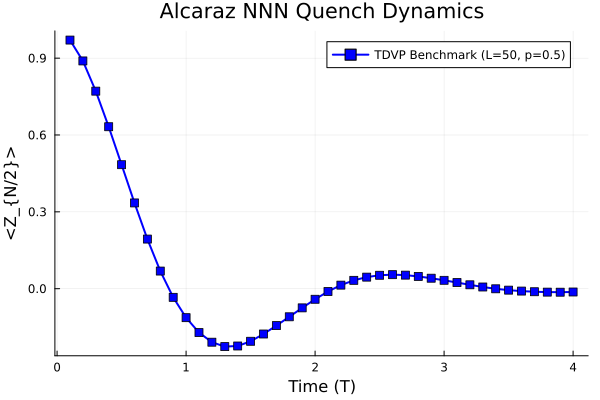

In [ ]:
# Initial state: Up state
psi0 = MPS(sites, "Up")
psi_t = copy(psi0)

# We want to measure the observable Z in the middle of the chain
center_site = div(N, 2)
z_vals_tdvp = Float64[]
times = dt:dt:T_max

@showprogress for t in times
    global psi_t = tdvp(H, -im*dt, psi_t; cutoff=cutoff, maxdim=maxdim, nsweeps=2)
    
    val = expect(psi_t, "Z")[center_site]
    push!(z_vals_tdvp, real(val))
end

plot(times, z_vals_tdvp, 
     label="TDVP Benchmark (L=$N, p=$p)", 
     xlabel="Time (T)", 
     ylabel="<Z_{N/2}>",
     lw=2, color=:blue, marker=:square,
     title="Alcaraz NNN Quench Dynamics")

To build $U(\delta t) \approx e^{-i H \delta t}$ for the Alcaraz model, we will use a classic tensor network technique:

1. We first calculate the exact matrix exponential $e^{-i \delta t \cdot h}$ for every single term in the Hamiltonian independently.
2. For the NNN term ($Z_i Z_{i+2}$), the interaction "jumps over", so we mathematically sandwich an Identity matrix in the middle: $Z_i \otimes \mathbb{I}_{i+1} \otimes Z_{i+2}$.
3. We use 2nd-order Trotter expansion to reduce Trotter error.
4. At the end, we create an MPO representing a pure Identity matrix and we "apply" our array of gates to it (so that ITensors sweeps across the chain, absorbs the gates, and compresses the result into our final $U(\delta t)$ MPO).

In [9]:
# Custom Struct with our model's parameters
import ITransverse: ModelParams, modelparams

struct AlcarazModel <: ModelParams
    lambda::Float64
    p::Float64
    phys_site::Index
end

ITransverse.modelparams(mp::AlcarazModel) = (mp.lambda, mp.p)

function expH_alcaraz(sites::Vector{<:Index}, lambda::Number, p::Number; dt::Number)
    N = length(sites)
    
    # 2nd order Trotterization
    dt_half = dt / 2.0

    gates = ITensor[]
    
    # Half-step NNN (Forward)
    for j=1:N-2
        h_NNN = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im * dt_half * h_NNN))
    end
    
    # Half-step NN (Forward)
    for j=1:N-1
        h_ZZ = -1.0 * op("Z", sites[j]) * op("Z", sites[j+1])
        h_XX = -p * lambda * op("X", sites[j]) * op("X", sites[j+1])
        push!(gates, exp(-im * dt_half * (h_ZZ + h_XX)))
    end
    
    # Full-step Transverse Field (Center)
    for j=1:N
        h_X = -lambda * op("X", sites[j])
        push!(gates, exp(-im * dt * h_X))
    end
    
    # Half-step NN (Reverse order for perfect symmetry)
    for j=N-1:-1:1
        h_ZZ = -1.0 * op("Z", sites[j]) * op("Z", sites[j+1])
        h_XX = -p * lambda * op("X", sites[j]) * op("X", sites[j+1])
        push!(gates, exp(-im * dt_half * (h_ZZ + h_XX)))
    end
    
    # Half-step NNN (Reverse order for perfect symmetry)
    for j=N-2:-1:1
        h_NNN = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im * dt_half * h_NNN))
    end
    
    U_dt = MPO(sites, "Id") 
    U_dt = apply(gates, U_dt; cutoff=1e-10, maxdim=200)
    
    return U_dt
end

expH_alcaraz (generic function with 1 method)

## Light Cone Evolution & Entropy

In [8]:
println(fb.WWc)

ITensor ord=4
Dim 1: (dim=16|id=561|"Site,time")'
Dim 2: (dim=16|id=561|"Site,time")
Dim 3: (dim=4|id=880|"Link,time")
Dim 4: (dim=4|id=272|"Link,time")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 16×16×4×4
[:, :, 1, 1] =
    0.48884503732848994 - 1.2041350604903618e-20im  …     6.96220062360671e-31 + 1.0237613974298195e-47im
  0.0024195368659692216 - 0.04880008521604918im          2.516217679379827e-30 + 9.480046794565044e-31im
   7.287442023754392e-6 + 0.002505973885286194im       -3.8625113986358517e-31 - 1.6369063352015621e-31im
  -4.94923550227632e-18 - 1.8464770742415812e-18im       7.044390295159562e-17 + 1.2646550842155029e-17im
  0.0024195368659692216 + 0.048800085216049185im         2.516217679379827e-30 - 9.480046794565044e-31im
   0.004883556737705505 - 1.3608014864848384e-21im  …    1.038473993090644e-29 - 1.564252941121919e-46im
 -0.0002501285634088586 + 1.313079504182216e-5im         -1.61884365920757e-30 - 6.565938048555151e-32im
  1.598326153485029e-19 - 5.0320800

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter C:\Users\jmarq\.julia\packages\ProgressMeter\N660J\src\ProgressMeter.jl:607
[cone(v=1)|RTM_LR] [psi0 >> Op] cutoff=1.0e-15, maxdim=400) 100% Time: 0:34:37 (53.26  s/it)
   Info: [40] χ=153, (L|R) = 1.405252486783992e-22 + 1.1233600483981986e-36im 


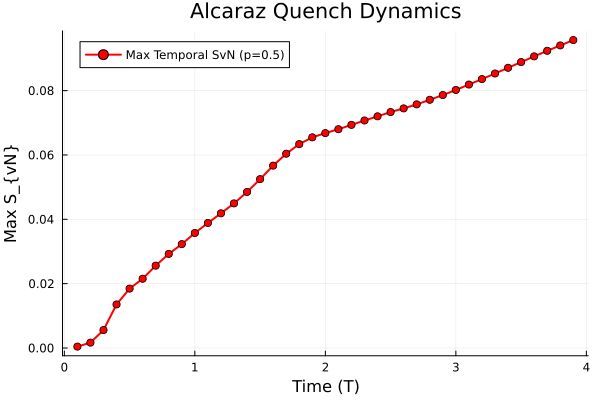

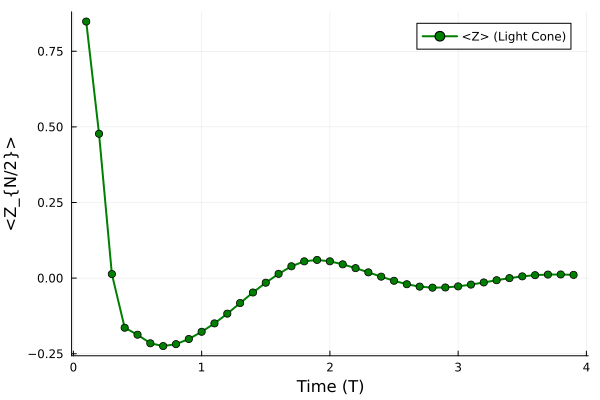

In [10]:
# Parameters
dt = 0.1
T_max = 4.0     
maxdim = 400 
cutoff = 1e-15

# Initial State (for Light Cone)
s = Index(2, "S=1/2")
bl = ITensor(ComplexF64, s)
bl[s => 1] = 1.0 + 0.0im  # Starting in the "Up" state

# Folded W Blocks
mp_alcaraz = AlcarazModel(lambda, p, s)
tp = tMPOParams(dt, expH_alcaraz, mp_alcaraz, 0, bl)
fb = FoldtMPOBlocks(tp)

# Cone Parameters
t_params = TruncParams(cutoff, maxdim, "left")

cp = ConeParams(
    truncp = t_params,
    opt_method = "RTM_LR",       
    vwidth = 1                   
)

# Checkpoint to measure Von Neumann Entropy
chk = DoCheckpoint(
    "cp_alcaraz_entropy.jld2";
    params=tp,
    save_at=0, 
    observables = (
        SvN = s -> vn_entanglement_entropy(s.R), 
        Z_normed = s -> real(
            first(compute_expvals(s.L, s.R, ["Z"], s.b)["Z"]) / 
            first(compute_expvals(s.L, s.R, ["Id"], s.b)["Id"])
        )
    )
)

# Running simulation
init_mps = init_cone(fb, 1)
Nt_final = Int(round(T_max / dt))

L_final, R_final, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)

# Entropy
svn_vals_raw = checkpt.history[:SvN]
svn_max = [maximum(real(v)) for v in svn_vals_raw]

# <Z>
z_vals = checkpt.history[:Z_normed]

times_plot = [n * dt for n in 1:length(svn_max)]

# Plot Ent Entropy
p1 = plot(times_plot, svn_max, 
     label="Max Temporal SvN (p=$p)", 
     xlabel="Time (T)", 
     ylabel="Max S_{vN}", 
     lw=2, color=:red, marker=:circle,
     title="Alcaraz Quench Dynamics")

display(p1)

# Plot <Z>
p2 = plot(times_plot, z_vals, 
     label="<Z> (Light Cone)", 
     xlabel="Time (T)", 
     ylabel="<Z_{N/2}>", 
     lw=2, color=:green, marker=:circle)

display(p2)

## Generalized Temporal Entropy

We want to study Reduced Transition Matrices (RTD):
$$\tau = \frac{|R\rangle\langle L|}{\langle L|R\rangle},$$

which is non-Hermitian.

In [ ]:

# Checkpoint to measure standard Entropy, <Z>, AND Pseudo Entropy
chk = DoCheckpoint(
    "cp_alcaraz_final.jld2";
    params=tp,
    save_at=0, 
    observables = (
        SvN_standard = s -> vn_entanglement_entropy(s.R), 
        
        # Pseudo Entropy
        SvN_pseudo = s -> vn_entanglement_entropy(s.L, s.R),
        
        Z_normed = s -> real(
            first(compute_expvals(s.L, s.R, ["Z"], s.b)["Z"]) / 
            first(compute_expvals(s.L, s.R, ["Id"], s.b)["Id"])
        )
    )
)

# Running simulation
init_mps = init_cone(fb, 1)
Nt_final = Int(round(T_max / dt))

println("Igniting Final Light Cone (dt=$dt, maxdim=$maxdim)...")
L_final, R_final, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)


# Standard Entropy
svn_raw = checkpt.history[:SvN_standard]
svn_max = [maximum(real(v)) for v in svn_raw]

# Pseudo Entropy
svn_pseudo_raw = checkpt.history[:SvN_pseudo]
svn_pseudo_max = [maximum(real(v)) for v in svn_pseudo_raw]

times_plot_lc = [n * dt for n in 1:length(svn_max)]

p3 = plot(times_plot_lc, svn_max, 
     label="Standard S_{vN} (|R>)", 
     xlabel="Time (T)", ylabel="Entropy", 
     lw=2, color=:red, marker=:circle,
     title="Temporal Entropies (Alcaraz Model)")

plot!(p3, times_plot_lc, svn_pseudo_max, 
     label="Pseudo S_{vN} (<L|R>)", 
     lw=2, color=:purple, marker=:square)

display(p3)